In [ ]:
# 1. Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_validate,
    GridSearchCV
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.inspection import permutation_importance



In [43]:
# 2. Settings


DATA_PATH = "dados_educacionais_unificados_final.csv"
RANDOM_STATE = 42

target = "final_grade"

column_translation = {
    # Demographics
    "idade": "age",
    "genero": "gender",
    "gender": "gender",
    "age_band": "age_band",
    "disability": "disability",

    # Parents / family
    "educacao_mae": "mother_education",
    "educacao_pai": "father_education",
    "relacoes_familiares": "family_relationship_quality",
    "tamanho_familia": "family_size",
    "status_coabitacao": "cohabitation_status",

    # Study behaviour
    "tempo_estudo": "study_time",
    "tempo_livre": "free_time",
    "saida_amigos": "social_outings",

    # Academic difficulty
    "tentativas_reprovacao": "past_failures",

    # Academic scores
    "nota1_uci": "grade_period1",
    "nota2_uci": "grade_period2",
    "resultado_uci": "final_grade",

    # OULAD engagement
    "oulad_total_cliques": "total_clicks",
    "oulad_media_notas": "average_assessment_score",
    "num_avaliacoes_submetidas": "submitted_assessments",

    # Mathematics subdomains
    "nota_numeros_inteiros": "integer_numbers_score",
    "nota_fracoes": "fractions_score",
    "nota_equacoes": "equations_score",
    "nota_geometria_basica": "basic_geometry_score",
    "nota_funcoes": "functions_score",
    "nota_trigonometria": "trigonometry_score",
    "nota_probabilidade": "probability_score",
    "nota_estatistica": "statistics_score",

    # Support variables
    "apoio_educacional": "educational_support",
    "apoio_familia": "family_support",
    "internet_acesso": "internet_access",

    # Location / household
    "endereco": "address_type",

    # IDs / metadata
    "id_aluno_origem": "source_student_id",
    "origem_dado": "data_source",

    # OULAD module info
    "code_module": "module_code",
    "code_presentation": "presentation_code",
    "resultado_final_curso_oulad": "oulad_final_result"
}

# remove duplicate columns after translation
df = df.loc[:, ~df.columns.duplicated()].copy()

predictors = []

for col in candidate_predictors:
    if col in df.columns and col not in predictors:
        predictors.append(col)

available_columns = predictors + [target]

model_raw = df[available_columns].copy()

model_raw = model_raw.dropna(subset=[target])

X = model_raw.drop(columns=[target])
y = model_raw[target]

# Final safety check
X = X.loc[:, ~X.columns.duplicated()].copy()

print("Duplicate columns in X:")
print(X.columns[X.columns.duplicated()].tolist())

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

# Remove duplicate feature names
numeric_features = list(dict.fromkeys(numeric_features))
categorical_features = list(dict.fromkeys(categorical_features))

candidate_predictors = [
    # Earlier academic performance
    "grade_period1",
    "grade_period2",

    # Behavioural variables
    "study_time",
    "free_time",
    "social_outings",

    # Academic difficulty
    "past_failures",

    # Support variables
    "family_support",
    "educational_support",

    # Engagement variables
    "total_clicks",
    "submitted_assessments",

    # Access
    "internet_access",

    # Demographics
    "age",
    "gender",
    "disability"
]

# 3. Load and rename data

df = pd.read_csv(DATA_PATH, low_memory=False)
df.rename(columns=column_translation, inplace=True)

print("Dataset loaded.")
print("Shape:", df.shape)


# 4. Select predictors

predictors = [
    col for col in candidate_predictors
    if col in df.columns
]

if target not in df.columns:
    raise ValueError(f"Target variable '{target}' was not found in the dataset.")

available_columns = predictors + [target]

model_raw = df[available_columns].copy()

print("\nTarget:")
print(target)

print("\nPredictors used:")
print(predictors)


# 5. Missing-data report

before_rows = model_raw.shape[0]

rows_with_missing_outcome = model_raw[target].isna().sum()
after_removing_missing_outcome = before_rows - rows_with_missing_outcome

complete_case_rows = model_raw.dropna().shape[0]

missing_report = pd.DataFrame({
    "rows_before_cleaning": [before_rows],
    "rows_after_removing_missing_outcome": [after_removing_missing_outcome],
    "complete_case_rows": [complete_case_rows],
    "rows_removed_if_complete_case": [before_rows - complete_case_rows],
    "percent_removed_if_complete_case": [
        ((before_rows - complete_case_rows) / before_rows) * 100
    ]
})

print("\nMISSING DATA IMPACT")
print(missing_report)

missing_report.to_csv(
    "missing_data_impact_report.csv",
    index=False
)

print("\nMissing values by variable:")
print(model_raw.isna().sum())

# 6. Remove missing outcome only

model_raw = model_raw.dropna(subset=[target])

X = model_raw.drop(columns=[target])
y = model_raw[target]

Duplicate columns in X:
[]
Dataset loaded.
Shape: (33687, 37)

Target:
final_grade

Predictors used:
['grade_period1', 'grade_period2', 'study_time', 'free_time', 'social_outings', 'past_failures', 'family_support', 'educational_support', 'total_clicks', 'submitted_assessments', 'internet_access', 'age', 'gender', 'disability']

MISSING DATA IMPACT
   rows_before_cleaning  rows_after_removing_missing_outcome  \
0                 33687                                33687   

   complete_case_rows  rows_removed_if_complete_case  \
0               33687                              0   

   percent_removed_if_complete_case  
0                               0.0  

Missing values by variable:
grade_period1            0
grade_period2            0
study_time               0
free_time                0
social_outings           0
past_failures            0
family_support           0
educational_support      0
total_clicks             0
submitted_assessments    0
internet_access          0
age  

In [44]:
# 7. Identify numeric and categorical features

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("\nNumeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

# 8. Preprocessing pipeline

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_transformer, numeric_features),
    ("categorical", categorical_transformer, categorical_features)
])

# 9. Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("\nTraining set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

# 10. Cross-validation setup

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)


Numeric features:
['grade_period1', 'grade_period2', 'study_time', 'free_time', 'social_outings', 'past_failures', 'total_clicks', 'submitted_assessments', 'age']

Categorical features:
['family_support', 'educational_support', 'internet_access', 'gender', 'gender', 'disability']

Training set shape: (26949, 15)
Testing set shape: (6738, 15)


In [45]:
# HARD RESET BEFORE MODELLING

# 1. Remove duplicate columns from X
X = X.loc[:, ~X.columns.duplicated()].copy()

# 2. Recreate train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

# 3. Recreate feature lists from cleaned X
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

# 4. Force unique feature lists
numeric_features = list(dict.fromkeys(numeric_features))
categorical_features = list(dict.fromkeys(categorical_features))

print("Duplicate columns in X:")
print(X.columns[X.columns.duplicated()].tolist())

print("Numeric features:")
print(numeric_features)

print("Categorical features:")
print(categorical_features)

# 5. Rebuild preprocessing pipeline from scratch
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_transformer, numeric_features),
    ("categorical", categorical_transformer, categorical_features)
])

Duplicate columns in X:
[]
Numeric features:
['grade_period1', 'grade_period2', 'study_time', 'free_time', 'social_outings', 'past_failures', 'total_clicks', 'submitted_assessments', 'age']
Categorical features:
['family_support', 'educational_support', 'internet_access', 'gender', 'disability']


In [46]:
# 11. Define models

models = {
    "Ridge Regression": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=1.0))
    ]),

    "Lasso Regression": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", Lasso(alpha=0.1, max_iter=10000))
    ]),

    "Random Forest": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=300,
            min_samples_leaf=5,
            random_state=RANDOM_STATE
        ))
    ]),

    "Gradient Boosting": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(
            random_state=RANDOM_STATE
        ))
    ])
}


In [47]:
# 12. Evaluate models

model_results = []

for name, model in models.items():

    cv_scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "rmse": "neg_root_mean_squared_error",
            "mae": "neg_mean_absolute_error",
            "r2": "r2"
        }
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    model_results.append({
        "model": name,
        "cv_rmse_mean": -cv_scores["test_rmse"].mean(),
        "cv_rmse_sd": cv_scores["test_rmse"].std(),
        "cv_mae_mean": -cv_scores["test_mae"].mean(),
        "cv_r2_mean": cv_scores["test_r2"].mean(),
        "test_rmse": np.sqrt(mean_squared_error(y_test, y_pred)),
        "test_mae": mean_absolute_error(y_test, y_pred),
        "test_r2": r2_score(y_test, y_pred)
    })

results_df = pd.DataFrame(model_results).sort_values("test_rmse")

print("\nMODEL COMPARISON")
print(results_df)

results_df.to_csv(
    "model_comparison_results.csv",
    index=False
)


MODEL COMPARISON
               model  cv_rmse_mean  cv_rmse_sd  cv_mae_mean  cv_r2_mean  \
3  Gradient Boosting      0.288060    0.041801     0.030797    0.822622   
0   Ridge Regression      0.269392    0.043673     0.030106    0.843783   
2      Random Forest      0.272490    0.045093     0.029193    0.840542   
1   Lasso Regression      0.285963    0.045247     0.033864    0.823564   

   test_rmse  test_mae   test_r2  
3   0.307661  0.032382  0.779940  
0   0.311320  0.032470  0.774675  
2   0.315608  0.031894  0.768424  
1   0.329355  0.036476  0.747812  


In [48]:
# 13. Tune Ridge and Lasso

alpha_grid = {
    "model__alpha": np.logspace(-3, 3, 100)
}

ridge_grid = GridSearchCV(
    Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge())
    ]),
    param_grid=alpha_grid,
    cv=cv,
    scoring="neg_root_mean_squared_error"
)

lasso_grid = GridSearchCV(
    Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", Lasso(max_iter=10000))
    ]),
    param_grid=alpha_grid,
    cv=cv,
    scoring="neg_root_mean_squared_error"
)

ridge_grid.fit(X_train, y_train)
lasso_grid.fit(X_train, y_train)

print("\nBest Ridge alpha:")
print(ridge_grid.best_params_)

print("\nBest Lasso alpha:")
print(lasso_grid.best_params_)


# 14. Evaluate tuned models


tuned_models = {
    "Tuned Ridge": ridge_grid.best_estimator_,
    "Tuned Lasso": lasso_grid.best_estimator_
}

tuned_results = []

for name, model in tuned_models.items():

    y_pred = model.predict(X_test)

    tuned_results.append({
        "model": name,
        "test_rmse": np.sqrt(mean_squared_error(y_test, y_pred)),
        "test_mae": mean_absolute_error(y_test, y_pred),
        "test_r2": r2_score(y_test, y_pred)
    })

tuned_results_df = pd.DataFrame(tuned_results).sort_values("test_rmse")

print("\nTUNED MODEL RESULTS")
print(tuned_results_df)

tuned_results_df.to_csv(
    "tuned_model_results.csv",
    index=False
)


Best Ridge alpha:
{'model__alpha': np.float64(141.74741629268047)}

Best Lasso alpha:
{'model__alpha': np.float64(0.010722672220103232)}

TUNED MODEL RESULTS
         model  test_rmse  test_mae   test_r2
0  Tuned Ridge   0.310772  0.032965  0.775467
1  Tuned Lasso   0.312615  0.033550  0.772796


In [49]:
# 15. Select best model overall

all_results_for_selection = pd.concat(
    [
        results_df[["model", "test_rmse", "test_mae", "test_r2"]],
        tuned_results_df[["model", "test_rmse", "test_mae", "test_r2"]]
    ],
    ignore_index=True
)

best_model_name = all_results_for_selection.sort_values(
    "test_rmse"
).iloc[0]["model"]

all_models = {
    **models,
    **tuned_models
}

best_model = all_models[best_model_name]
best_model.fit(X_train, y_train)

print("\nBEST MODEL:")
print(best_model_name)

joblib.dump(
    best_model,
    "best_academic_performance_model.joblib"
)


BEST MODEL:
Gradient Boosting


['best_academic_performance_model.joblib']

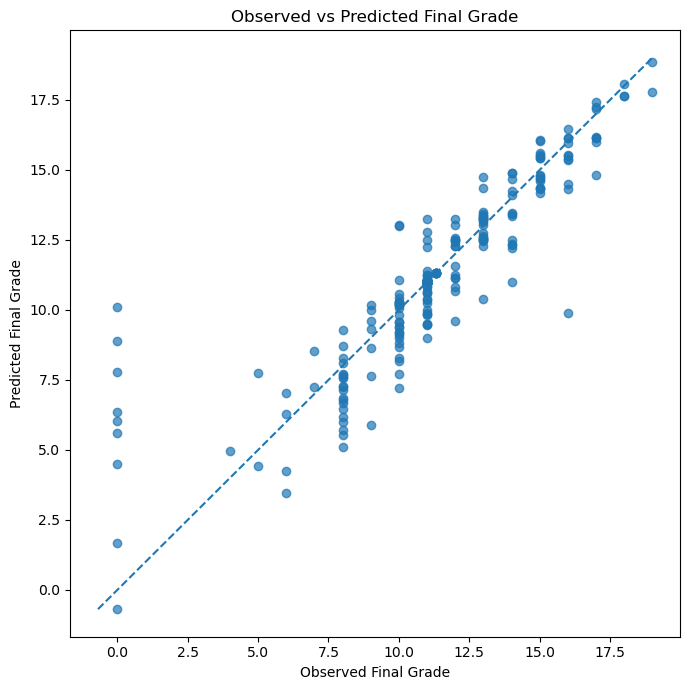

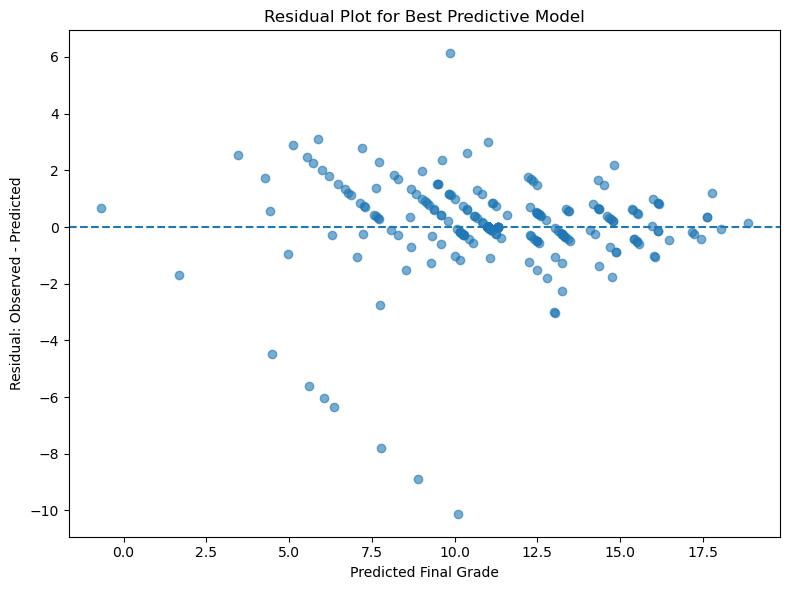

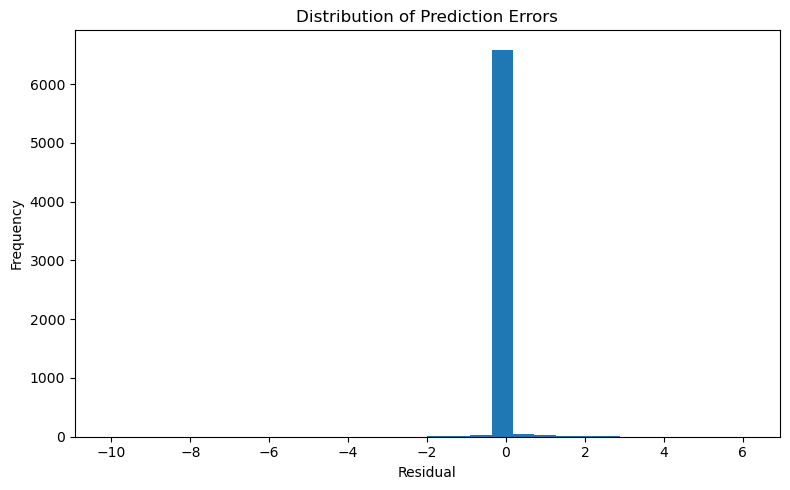

In [50]:
# 16. Prediction diagnostics

y_pred_best = best_model.predict(X_test)
residuals = y_test - y_pred_best

diagnostics_df = pd.DataFrame({
    "observed_final_grade": y_test,
    "predicted_final_grade": y_pred_best,
    "residual": residuals,
    "absolute_error": np.abs(residuals)
})

diagnostics_df.to_csv(
    "prediction_diagnostics.csv",
    index=False
)

# Observed vs predicted plot

plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    y_pred_best,
    alpha=0.7
)

min_value = min(y_test.min(), y_pred_best.min())
max_value = max(y_test.max(), y_pred_best.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Observed Final Grade")
plt.ylabel("Predicted Final Grade")
plt.title("Observed vs Predicted Final Grade")

plt.tight_layout()
plt.savefig("figure_1_observed_vs_predicted.png", dpi=300)
plt.show()

# Residual plot

plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred_best,
    residuals,
    alpha=0.6
)

plt.axhline(
    0,
    linestyle="--"
)



plt.xlabel("Predicted Final Grade")
plt.ylabel("Residual: Observed - Predicted")
plt.title("Residual Plot for Best Predictive Model")

plt.tight_layout()
plt.savefig("figure_2_residual_plot.png", dpi=300)
plt.show()


# Residual distribution

plt.figure(figsize=(8, 5))

plt.hist(
    residuals,
    bins=30
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")

plt.tight_layout()
plt.savefig("figure_3_residual_distribution.png", dpi=300)
plt.show()



ERROR BY PERFORMANCE GROUP
   performance_group  mean_error  mean_absolute_error     n
0   Lower-performing   -0.009356             0.064418  2251
1  Middle-performing   -0.000748             0.000748  2251
2  Higher-performing    0.012273             0.031976  2236


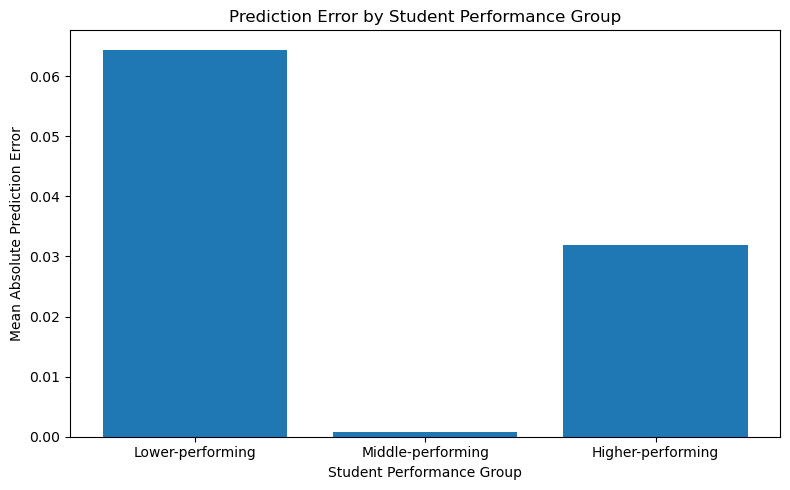

In [51]:
# 17. Error by performance group

performance_error_df = diagnostics_df.copy()

performance_error_df["performance_group"] = pd.qcut(
    performance_error_df["observed_final_grade"],
    q=3,
    labels=[
        "Lower-performing",
        "Middle-performing",
        "Higher-performing"
    ],
    duplicates="drop"
)

error_by_performance = performance_error_df.groupby(
    "performance_group",
    observed=True
).agg(
    mean_error=("residual", "mean"),
    mean_absolute_error=("absolute_error", "mean"),
    n=("absolute_error", "count")
).reset_index()

print("\nERROR BY PERFORMANCE GROUP")
print(error_by_performance)

error_by_performance.to_csv(
    "error_by_performance_group.csv",
    index=False
)

plt.figure(figsize=(8, 5))

plt.bar(
    error_by_performance["performance_group"].astype(str),
    error_by_performance["mean_absolute_error"]
)

plt.xlabel("Student Performance Group")
plt.ylabel("Mean Absolute Prediction Error")
plt.title("Prediction Error by Student Performance Group")

plt.tight_layout()
plt.savefig("figure_4_error_by_performance_group.png", dpi=300)
plt.show()

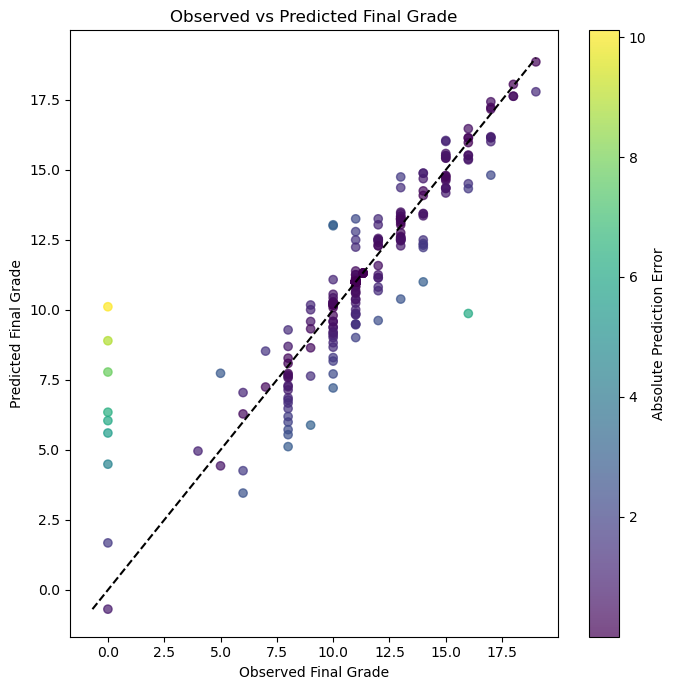

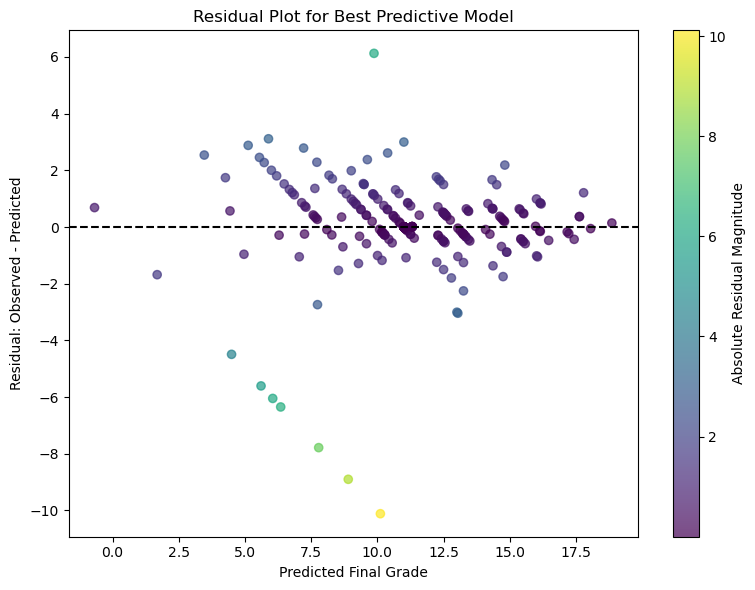

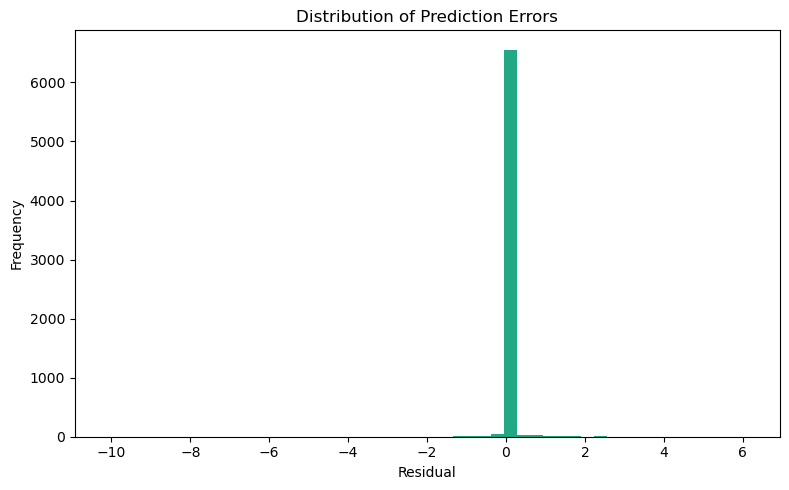

In [52]:
plt.figure(figsize=(7, 7))

scatter = plt.scatter(
    y_test,
    y_pred_best,
    c=np.abs(y_test - y_pred_best),
    cmap="viridis",
    alpha=0.7
)

min_value = min(y_test.min(), y_pred_best.min())
max_value = max(y_test.max(), y_pred_best.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    color="black"
)

plt.xlabel("Observed Final Grade")
plt.ylabel("Predicted Final Grade")
plt.title("Observed vs Predicted Final Grade")

cbar = plt.colorbar(scatter)
cbar.set_label("Absolute Prediction Error")

plt.tight_layout()

plt.savefig(
    "figure_1_observed_vs_predicted_viridis.png",
    dpi=300
)

plt.show()

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    y_pred_best,
    residuals,
    c=np.abs(residuals),
    cmap="viridis",
    alpha=0.7
)

plt.axhline(
    0,
    linestyle="--",
    color="black"
)

plt.xlabel("Predicted Final Grade")
plt.ylabel("Residual: Observed - Predicted")
plt.title("Residual Plot for Best Predictive Model")

cbar = plt.colorbar(scatter)
cbar.set_label("Absolute Residual Magnitude")

plt.tight_layout()

plt.savefig(
    "figure_2_residual_plot_viridis.png",
    dpi=300
)

plt.show()

plt.figure(figsize=(8, 5))

plt.hist(
    residuals,
    bins=50,
    color=plt.cm.viridis(0.6)
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")

plt.tight_layout()

plt.savefig(
    "figure_3_residual_distribution_viridis.png",
    dpi=300
)

plt.show()

In [53]:
# 18. Fairness / subgroup error checks

fairness_columns = [
    "gender",
    "internet_access",
    "family_support",
    "educational_support",
    "disability"
]

fairness_columns = [
    col for col in fairness_columns
    if col in X_test.columns
]

group_summary = group_summary.dropna(
    axis=1,
    how="all"
)

fairness_results = []

fairness_df = X_test.copy()
fairness_df["observed"] = y_test
fairness_df["predicted"] = y_pred_best
fairness_df["absolute_error"] = np.abs(
    fairness_df["observed"] - fairness_df["predicted"]
)

for col in fairness_columns:

    group_summary = fairness_df.groupby(col, observed=True).agg(
        mean_observed=("observed", "mean"),
        mean_predicted=("predicted", "mean"),
        mean_absolute_error=("absolute_error", "mean"),
        n=("absolute_error", "count")
    ).reset_index()

    group_summary["subgroup_variable"] = col

    fairness_results.append(group_summary)

if fairness_results:

    fairness_results_df = pd.concat(
        fairness_results,
        ignore_index=True
    )

    print("\nFAIRNESS / SUBGROUP ERROR CHECKS")
    print(fairness_results_df)

    fairness_results_df.to_csv(
        "fairness_subgroup_error_checks.csv",
        index=False
    )

else:
    print("\nNo fairness columns were available in the test set.")


FAIRNESS / SUBGROUP ERROR CHECKS
  gender  mean_observed  mean_predicted  mean_absolute_error     n  \
0      F      11.006509       11.004010             0.020002  6650   
1      M      11.170455       11.305938             0.967924    88   
2    NaN       9.891892       10.291374             1.283331    37   
3    NaN      11.014816       11.011910             0.025474  6701   
4    NaN      11.542169       11.789340             1.144689    83   
5    NaN      11.001996       10.998208             0.018509  6655   
6    NaN      11.011667       11.013011             0.028430  6710   
7    NaN      10.285714        9.795813             0.979391    28   
8    NaN      11.009536       11.008691             0.035622  6112   
9    NaN      11.000000       11.000748             0.000748   626   

     subgroup_variable internet_access family_support educational_support  \
0               gender             NaN            NaN                 NaN   
1               gender             NaN   


PERMUTATION IMPORTANCE
                predictor  importance_mean  importance_sd
1           grade_period2         0.463334       0.005325
0           grade_period1         0.022105       0.001552
4          social_outings         0.008455       0.001539
12                 gender         0.006708       0.000346
5           past_failures         0.004177       0.000458
11                    age         0.002119       0.000098
6          family_support         0.000822       0.000015
10        internet_access         0.000269       0.000148
8            total_clicks         0.000000       0.000000
9   submitted_assessments         0.000000       0.000000
13             disability         0.000000       0.000000
7     educational_support        -0.000544       0.000137
3               free_time        -0.002293       0.000148
2              study_time        -0.002937       0.000748


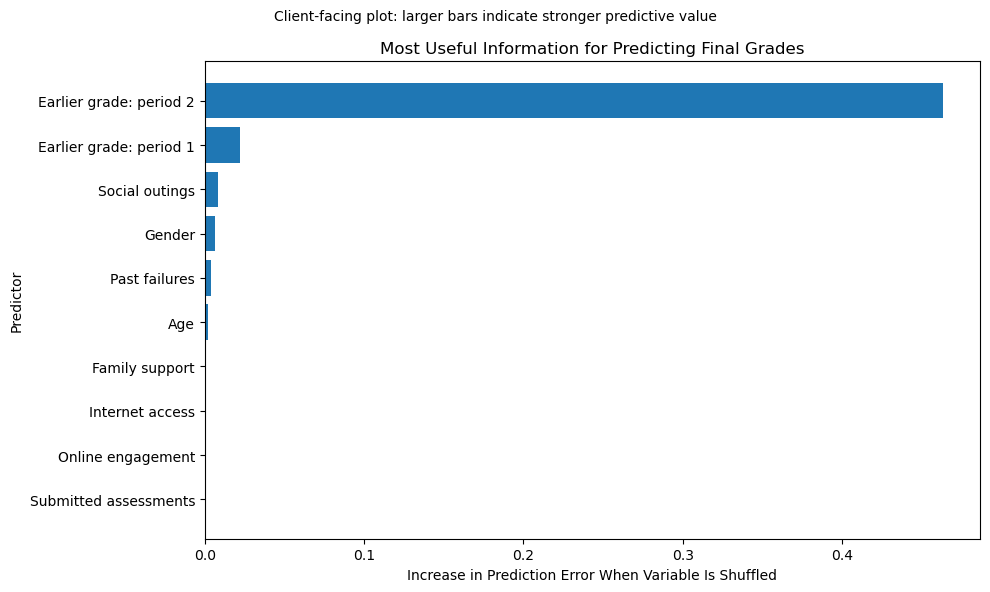

In [54]:
# 19. Permutation importance

perm_importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=20,
    random_state=RANDOM_STATE,
    scoring="neg_root_mean_squared_error"
)

importance_df = pd.DataFrame({
    "predictor": X_test.columns,
    "importance_mean": perm_importance.importances_mean,
    "importance_sd": perm_importance.importances_std
}).sort_values(
    "importance_mean",
    ascending=False
)

print("\nPERMUTATION IMPORTANCE")
print(importance_df)

importance_df.to_csv(
    "permutation_importance.csv",
    index=False
)

client_labels = {
    "grade_period1": "Earlier grade: period 1",
    "grade_period2": "Earlier grade: period 2",
    "study_time": "Study time",
    "free_time": "Free time",
    "social_outings": "Social outings",
    "past_failures": "Past failures",
    "family_support": "Family support",
    "educational_support": "Educational support",
    "total_clicks": "Online engagement",
    "submitted_assessments": "Submitted assessments",
    "internet_access": "Internet access",
    "age": "Age",
    "gender": "Gender",
    "disability": "Disability"
}

top_importance = importance_df.head(10).copy()

top_importance["client_label"] = top_importance["predictor"].replace(
    client_labels
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_importance["client_label"],
    top_importance["importance_mean"]
)

plt.xlabel("Increase in Prediction Error When Variable Is Shuffled")
plt.ylabel("Predictor")
plt.title("Most Useful Information for Predicting Final Grades")
plt.suptitle(
    "Client-facing plot: larger bars indicate stronger predictive value",
    y=0.98,
    fontsize=10
)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("figure_5_client_facing_predictor_importance.png", dpi=300)
plt.show()


In [55]:
# 20. Ridge coefficients, if available

if "Ridge" in best_model_name:

    fitted_preprocessor = best_model.named_steps["preprocessor"]
    fitted_model = best_model.named_steps["model"]

    feature_names = fitted_preprocessor.get_feature_names_out()

    coefficients = pd.DataFrame({
        "predictor": feature_names,
        "coefficient": fitted_model.coef_
    }).sort_values("coefficient")

    print("\nRIDGE COEFFICIENTS")
    print(coefficients)

    coefficients.to_csv(
        "ridge_coefficients.csv",
        index=False
    )

    plt.figure(figsize=(10, 8))

    plt.barh(
        coefficients["predictor"],
        coefficients["coefficient"]
    )

    plt.axvline(
        0,
        linestyle="--"
    )

    plt.xlabel("Standardised Coefficient")
    plt.ylabel("Predictor")
    plt.title("Ridge Regression Coefficients")

    plt.tight_layout()
    plt.savefig("figure_6_ridge_coefficients.png", dpi=300)
    plt.show()


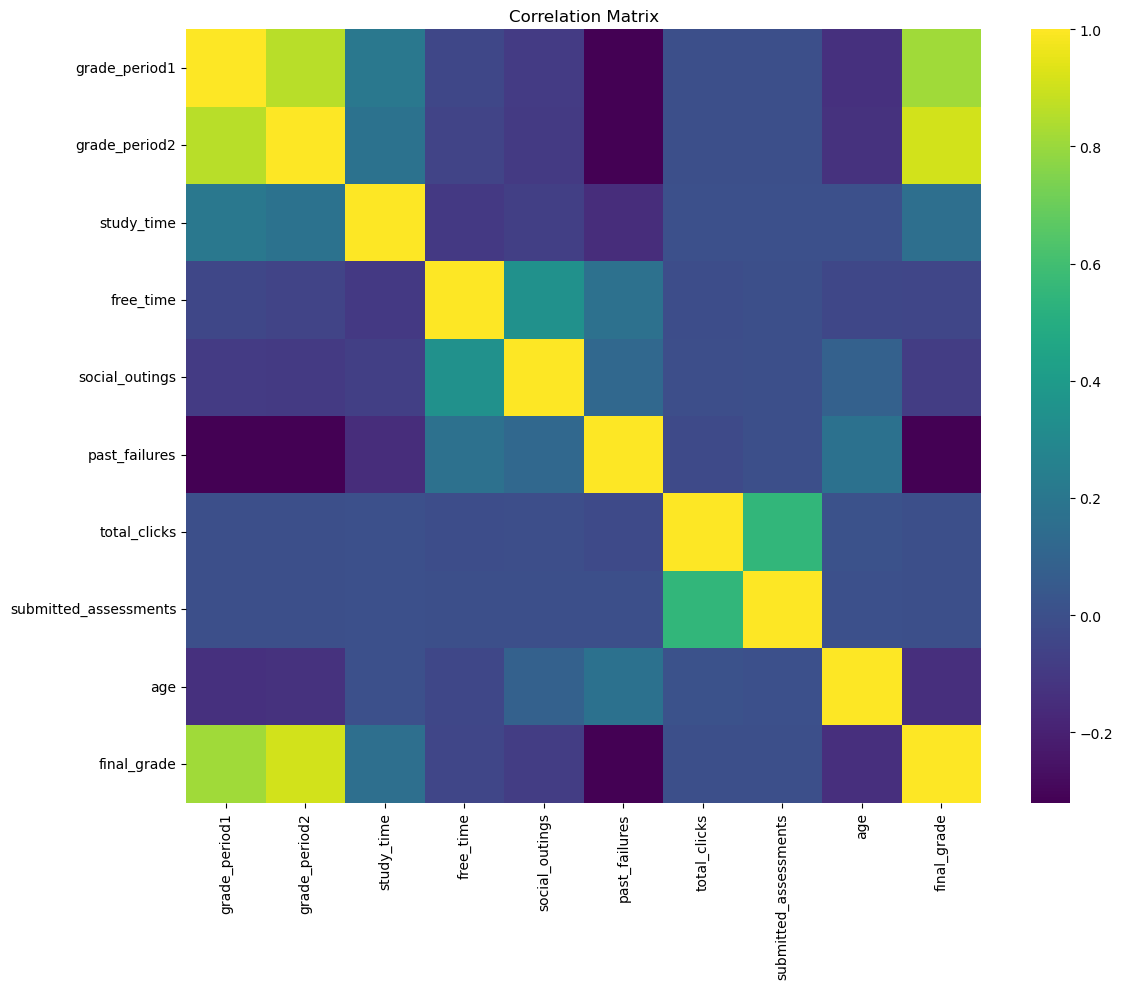

In [56]:
# 21. Correlation matrix

numeric_for_corr = model_raw.select_dtypes(
    include=["int64", "float64"]
)

if numeric_for_corr.shape[1] > 1:

    plt.figure(figsize=(12, 10))

    corr = numeric_for_corr.corr(numeric_only=True)

    sns.heatmap(
        corr,
        cmap="viridis"
    )



    plt.title("Correlation Matrix")

    plt.tight_layout()
    plt.savefig("figure_7_correlation_matrix.png", dpi=300)
    plt.show()

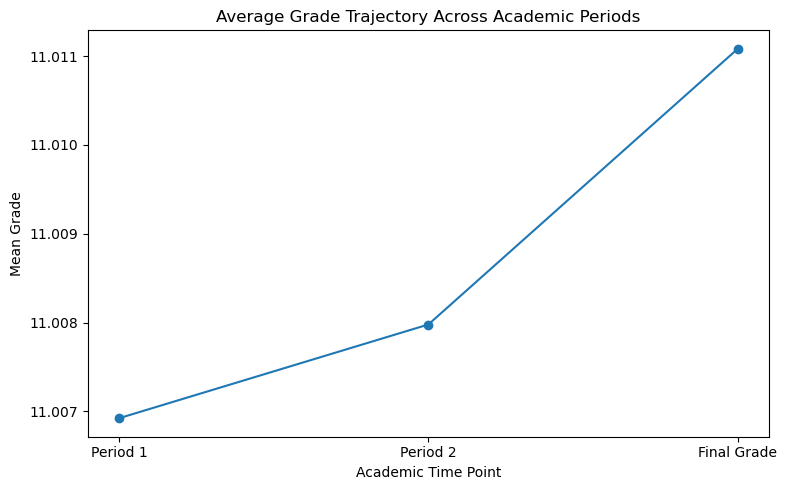

In [57]:
# 22. Simple time-ordered / longitudinal trajectory plot

trajectory_columns = [
    "grade_period1",
    "grade_period2",
    "final_grade"
]

trajectory_columns = [
    col for col in trajectory_columns
    if col in model_raw.columns
]

if len(trajectory_columns) == 3:

    trajectory_df = model_raw[trajectory_columns].copy()

    trajectory_long = trajectory_df.melt(
        value_vars=trajectory_columns,
        var_name="academic_period",
        value_name="grade"
    )

    period_labels = {
        "grade_period1": "Period 1",
        "grade_period2": "Period 2",
        "final_grade": "Final Grade"
    }

    trajectory_long["academic_period"] = trajectory_long[
        "academic_period"
    ].replace(period_labels)

    mean_trajectory = trajectory_long.groupby(
        "academic_period",
        observed=True
    )["grade"].mean().reindex([
        "Period 1",
        "Period 2",
        "Final Grade"
    ])

    plt.figure(figsize=(8, 5))

    plt.plot(
        mean_trajectory.index,
        mean_trajectory.values,
        marker="o"
    )

    plt.xlabel("Academic Time Point")
    plt.ylabel("Mean Grade")
    plt.title("Average Grade Trajectory Across Academic Periods")

    plt.tight_layout()
    plt.savefig("figure_8_longitudinal_grade_trajectory.png", dpi=300)
    plt.show()

else:
    print("\nTime-ordered grade columns were not all available.")


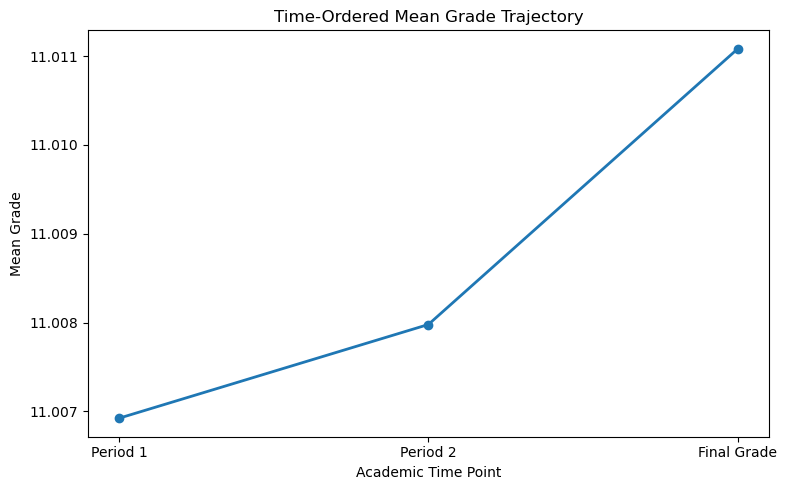

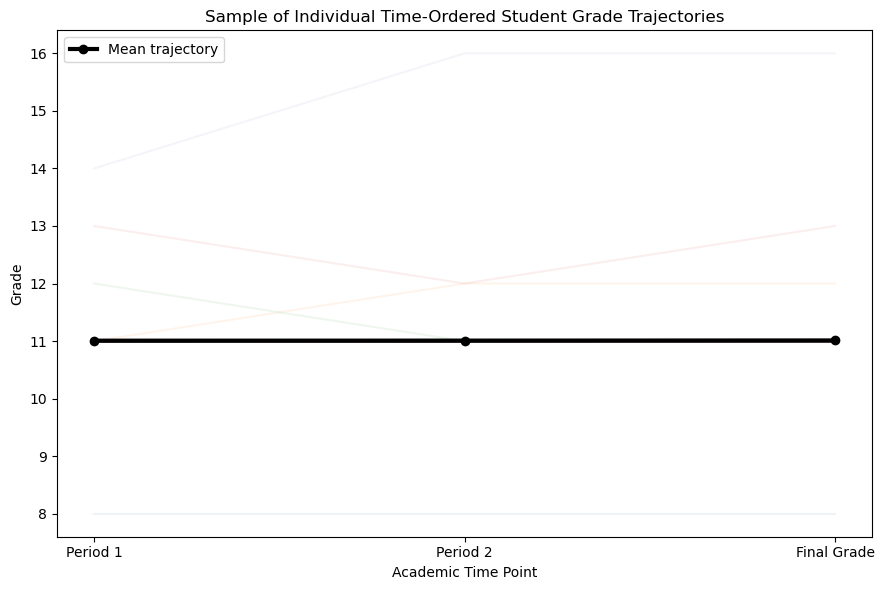


TIME-ORDERED / LONGITUDINAL ANALYSIS COMPLETE
       change_period1_to_period2  change_period2_to_final  \
count               33687.000000             33687.000000   
mean                    0.001055                 0.003104   
std                     0.297629                 0.284372   
min                   -12.000000               -10.000000   
25%                     0.000000                 0.000000   
50%                     0.000000                 0.000000   
75%                     0.000000                 0.000000   
max                    11.000000                 6.000000   

       overall_change_period1_to_final  
count                     33687.000000  
mean                          0.004160  
std                           0.401053  
min                         -12.000000  
25%                           0.000000  
50%                           0.000000  
75%                           0.000000  
max                          11.000000  


In [59]:

# TIME-ORDERED / LONGITUDINAL ANALYSIS

trajectory_columns = [
    "grade_period1",
    "grade_period2",
    "final_grade"
]

if all(col in model_raw.columns for col in trajectory_columns):

    trajectory_df = model_raw[trajectory_columns].copy()

    # Rename time points for plotting
    time_labels = {
        "grade_period1": "Period 1",
        "grade_period2": "Period 2",
        "final_grade": "Final Grade"
    }

    trajectory_long = trajectory_df.reset_index().melt(
        id_vars="index",
        value_vars=trajectory_columns,
        var_name="time_point",
        value_name="grade"
    )

    trajectory_long["time_point"] = trajectory_long["time_point"].replace(time_labels)

    trajectory_long["time_order"] = trajectory_long["time_point"].map({
        "Period 1": 1,
        "Period 2": 2,
        "Final Grade": 3
    })

    trajectory_long = trajectory_long.sort_values(["index", "time_order"])

    # Save long-format time-ordered data
    trajectory_long.to_csv(
        "longitudinal_grade_trajectory_long_format.csv",
        index=False
    )

    # Mean trajectory
    mean_trajectory = trajectory_long.groupby(
        "time_point",
        observed=True
    )["grade"].mean().reindex([
        "Period 1",
        "Period 2",
        "Final Grade"
    ])

    plt.figure(figsize=(8, 5))

    plt.plot(
        mean_trajectory.index,
        mean_trajectory.values,
        marker="o",
        linewidth=2
    )

    plt.xlabel("Academic Time Point")
    plt.ylabel("Mean Grade")
    plt.title("Time-Ordered Mean Grade Trajectory")

    plt.tight_layout()
    plt.savefig(
        "figure_time_ordered_mean_grade_trajectory.png",
        dpi=300
    )
    plt.show()

    # Individual student trajectories sample
    sample_students = trajectory_long["index"].drop_duplicates().sample(
        n=min(200, trajectory_long["index"].nunique()),
        random_state=42
    )

    sample_trajectory = trajectory_long[
        trajectory_long["index"].isin(sample_students)
    ]

    plt.figure(figsize=(9, 6))

    for student_id, student_data in sample_trajectory.groupby("index"):

        plt.plot(
            student_data["time_point"],
            student_data["grade"],
            alpha=0.08
        )

    plt.plot(
        mean_trajectory.index,
        mean_trajectory.values,
        marker="o",
        linewidth=3,
        color="black",
        label="Mean trajectory"
    )

    plt.xlabel("Academic Time Point")
    plt.ylabel("Grade")
    plt.title("Sample of Individual Time-Ordered Student Grade Trajectories")
    plt.legend()

    plt.tight_layout()
    plt.savefig(
        "figure_individual_longitudinal_grade_trajectories.png",
        dpi=300
    )
    plt.show()

    # Change-score features
    trajectory_df["change_period1_to_period2"] = (
        trajectory_df["grade_period2"] - trajectory_df["grade_period1"]
    )

    trajectory_df["change_period2_to_final"] = (
        trajectory_df["final_grade"] - trajectory_df["grade_period2"]
    )

    trajectory_df["overall_change_period1_to_final"] = (
        trajectory_df["final_grade"] - trajectory_df["grade_period1"]
    )

    trajectory_df.to_csv(
        "time_ordered_grade_change_scores.csv",
        index=False
    )

    print("\nTIME-ORDERED / LONGITUDINAL ANALYSIS COMPLETE")
    print(trajectory_df[
        [
            "change_period1_to_period2",
            "change_period2_to_final",
            "overall_change_period1_to_final"
        ]
    ].describe())

else:
    print("Required time-ordered grade columns are not available.")

In [60]:
# 23. Save cleaned modelling data

model_raw.to_csv(
    "cleaned_educational_dataset_for_modelling.csv",
    index=False
)

In [61]:
# 24. Save project summary

best_row = all_results_for_selection.sort_values(
    "test_rmse"
).iloc[0]

summary_text = f"""
PROJECT SUMMARY

Research Question 1:
How accurately can students' final grades be predicted from earlier academic
performance, study behaviour, support, engagement, access, and demographic
variables?

Research Question 2:
Which variables contribute most strongly to predictions of final academic
performance, and how could these predictions support early educational
intervention?

Best Predictive Model:
{best_model_name}

Best Model Test Performance:
RMSE: {best_row["test_rmse"]:.3f}
MAE: {best_row["test_mae"]:.3f}
R²: {best_row["test_r2"]:.3f}

Important Methodological Note:
This project is predictive, not causal. The models estimate associations useful
for forecasting final grades, but they do not prove that any predictor causes
academic performance.

Missing Data:
Rows before cleaning: {before_rows}
Rows after removing missing outcome: {after_removing_missing_outcome}
Complete-case rows: {complete_case_rows}
Percentage removed under complete-case deletion:
{missing_report["percent_removed_if_complete_case"].iloc[0]:.2f}%

Time-Series / Longitudinal Note:
The dataset contains ordered academic performance measures: period 1,
period 2, and final grade. This supports a simple time-ordered educational
trajectory and prediction framing. However, it is not a full classical time-series
dataset because there are too few repeated time points for decomposition,
seasonality analysis, ACF/PACF, or ARIMA-style forecasting.

The dataset contains three ordered academic measurement points: Period 1 grade, Period 2 grade, 
and final grade. This does not constitute a full classical time-series dataset with many repeated observations, 
but it does allow a short longitudinal analysis of academic progression. Therefore, 
I modelled final grade as a forecasting target using earlier academic performance and plotted both mean and individual grade trajectories over time.

Ethical Note:
Predictions should be used to identify students who may benefit from additional
support. They should not be used to punish, label, exclude, or rank students.
Special care is needed when using variables such as gender, disability, internet
access, and family support because these may reflect structural inequalities.
"""

with open("project_summary_for_report.txt", "w") as file:
    file.write(summary_text)

print(summary_text)

print("\nPROJECT PIPELINE COMPLETE")


PROJECT SUMMARY

Research Question 1:
How accurately can students' final grades be predicted from earlier academic
performance, study behaviour, support, engagement, access, and demographic
variables?

Research Question 2:
Which variables contribute most strongly to predictions of final academic
performance, and how could these predictions support early educational
intervention?

Best Predictive Model:
Gradient Boosting

Best Model Test Performance:
RMSE: 0.308
MAE: 0.032
R²: 0.780

Important Methodological Note:
This project is predictive, not causal. The models estimate associations useful
for forecasting final grades, but they do not prove that any predictor causes
academic performance.

Missing Data:
Rows before cleaning: 33687
Rows after removing missing outcome: 33687
Complete-case rows: 33687
Percentage removed under complete-case deletion:
0.00%

Time-Series / Longitudinal Note:
The dataset contains ordered academic performance measures: period 1,
period 2, and final grade. Th